# CDD 2026 Project
- Authors: Marek Cuker, Andrea Vaňková
- Target: Human Chemokine Receptor 5 (CCR5)

In [1]:
import pandas as pd
import numpy as np
import pickle as pkl
import os
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import MACCSkeys
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import Descriptors, Draw
from rdkit.Chem.Scaffolds.MurckoScaffold import GetScaffoldForMol
from chembl_structure_pipeline import standardizer as chembl_standardizer
from rdkit.Chem import rdMolDescriptors as rdescriptors
import warnings
warnings.filterwarnings('ignore')
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*') 

[11:26:16] Initializing Normalizer


# Processing

## Data Preprocessing
 - Structures loaded from input files using pandas and rdkit
 - Mol instances are created for each molecule
 - Molecules are standardized, and smiles regenerated for consistency
 - Data is deduplicated (in the order ChemBL > DrugBank > Zinc) to ensure no overlap between training and prediction sets

In [2]:
mols = Chem.SDMolSupplier('../data/drugbank.sdf')
drugbank = pd.DataFrame([mol.GetPropsAsDict() for mol in mols if mol is not None])
ccr5 = pd.read_csv('chembl_ccr5_ki.csv', sep=';', usecols=['Molecule ChEMBL ID', 'Smiles', 'Standard Value'])
zinc = pd.read_csv('../data/zinc_random_structures.txt', sep=' ', usecols=['zincid', 'SMILES'])

In [3]:
def make_df(data, id_col, source_name, smiles_col):
    df = pd.DataFrame({
        'id': data[id_col],
        'source': source_name,
        'smiles': data[smiles_col],
        'mol': data[smiles_col].apply(lambda x: Chem.MolFromSmiles(x) if pd.notna(x) else None),
        'ki': data['Standard Value'] if 'Standard Value' in data.columns else np.nan
    })
    return df[df['mol'].notna()]

drugbank = make_df(drugbank, 'DRUGBANK_ID', 'drugbank', 'SMILES')
ccr5 = make_df(ccr5, 'Molecule ChEMBL ID', 'chembl', 'Smiles')
zinc = make_df(zinc, 'zincid', 'zinc', 'SMILES')

structures = pd.concat([ccr5, drugbank, zinc], ignore_index=True)

In [4]:
structures['mol'] = structures['mol'].apply(chembl_standardizer.standardize_mol)
structures['smiles'] = structures['mol'].apply(Chem.MolToSmiles)
structures = structures.drop_duplicates(subset='smiles').reset_index(drop=True)

# Descriptors

## Molecular Descriptors Calculation
- Molar refractivity
- LogP
- H-bond acceptors
- H-bond donors
- Rings count
- Aromatic rings count
- Fraction $sp^3$
- Topological polar surface area
- Rotatable bonds count
- Heavy atoms count

In [5]:
# calculate molecular descriptors
desc_funcs = {
    'MolMR': Descriptors.MolMR, # polarizability (membrane permeability)
    'MolLogP': Descriptors.MolLogP, # hydrophobicity 
    'HBA': Descriptors.NumHAcceptors,
    'HBD': Descriptors.NumHDonors,
    'NumRings': lambda m: len(Chem.GetSSSR(m)) if m else np.nan,
    'AromaticRings': Descriptors.NumAromaticRings,
    'FractionCSP3': Descriptors.FractionCSP3, # saturation of organic molecule (higher -> more 3D)
    'TPSA': rdescriptors.CalcTPSA,
    'NumRotatableBonds': rdescriptors.CalcNumRotatableBonds,
    'HeavyAtomMolWt': Descriptors.HeavyAtomMolWt
}

for desc, fn in desc_funcs.items():
    structures[desc] = structures['mol'].apply(lambda m: fn(m) if m else np.nan)


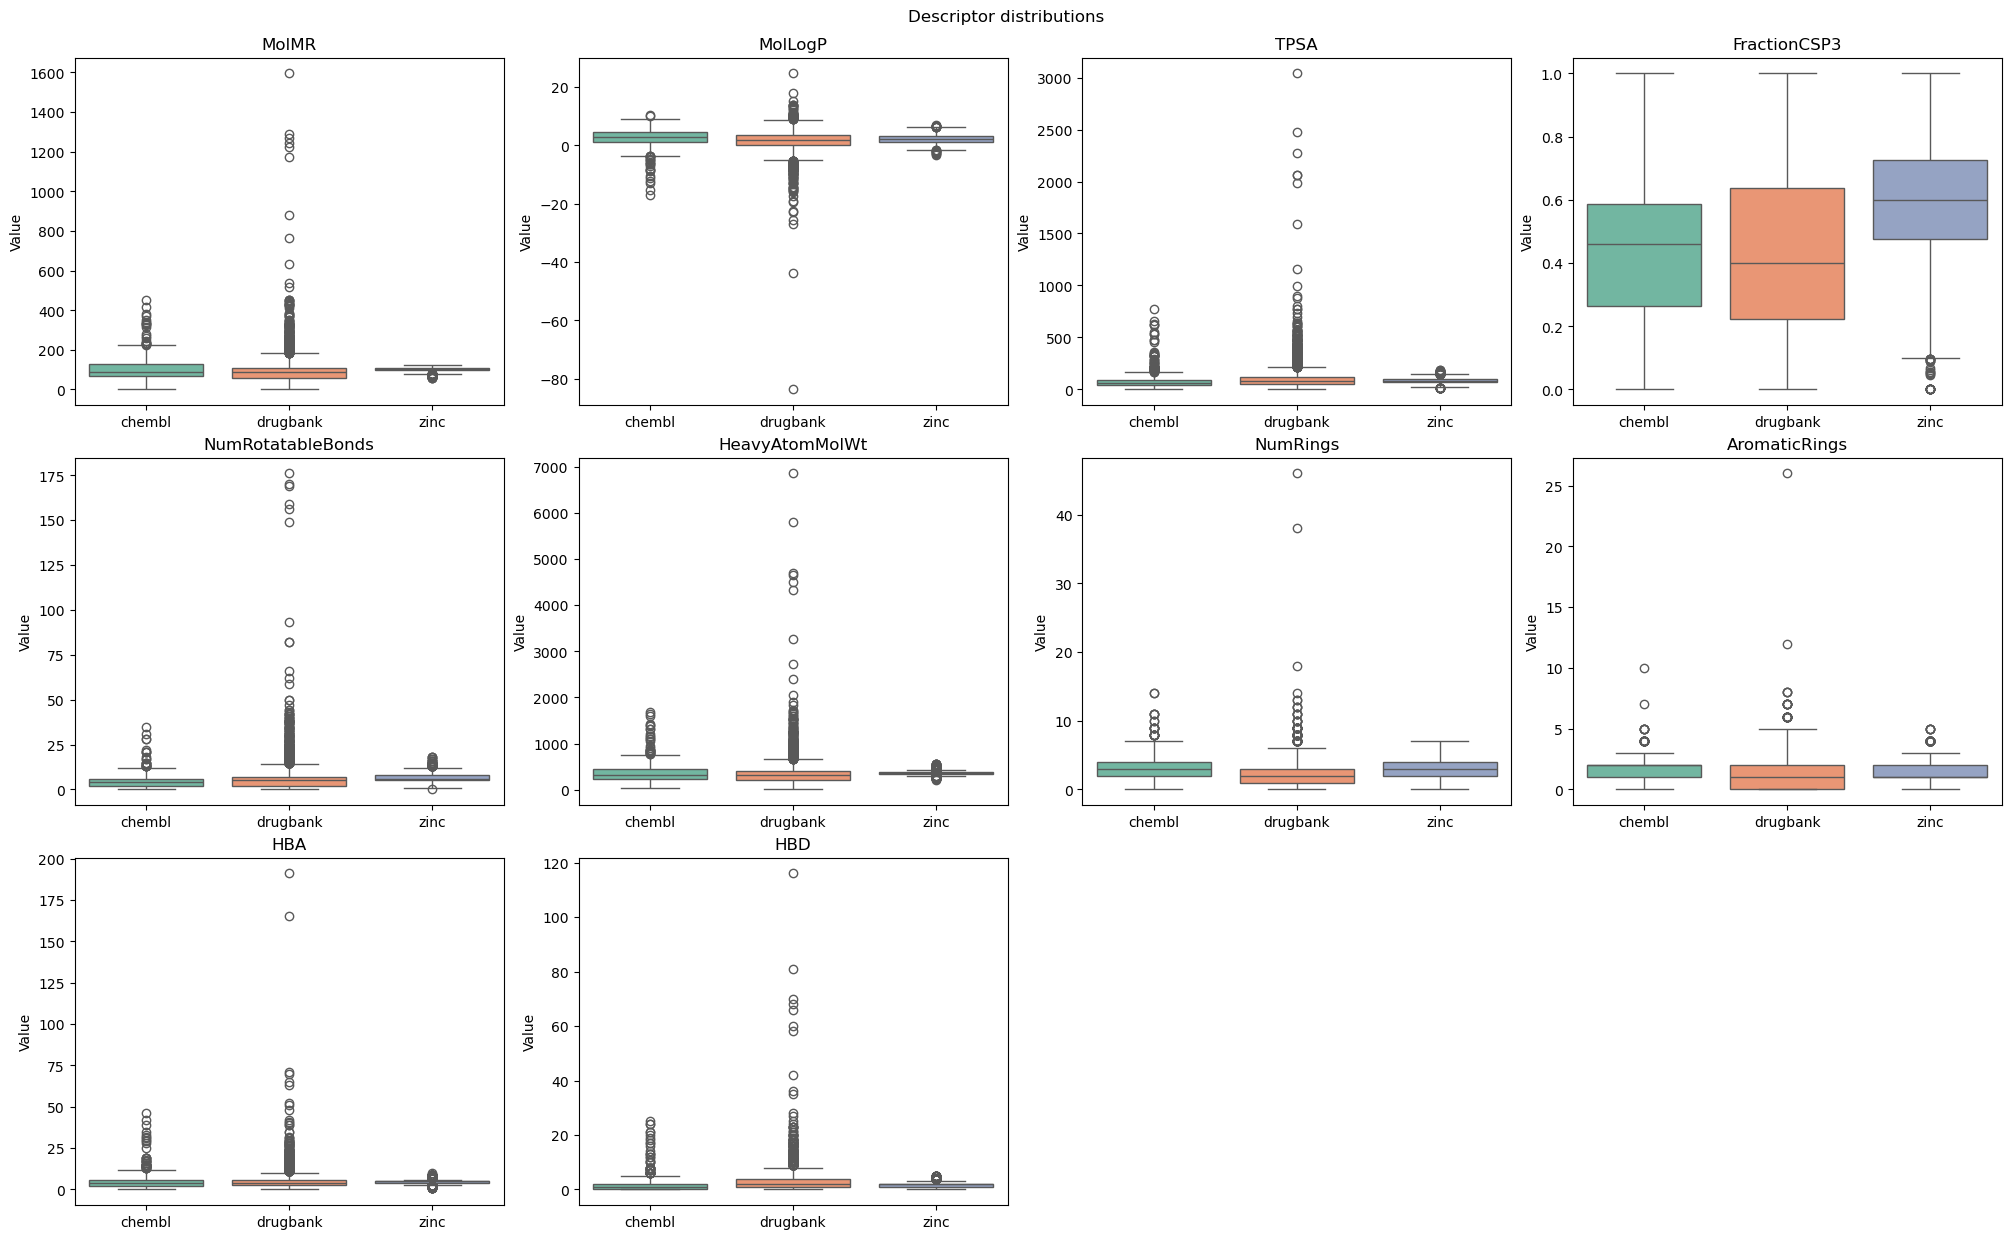

In [6]:
descriptors = ['MolMR', 'MolLogP', 'TPSA', 'FractionCSP3', 'NumRotatableBonds', 'HeavyAtomMolWt', 'NumRings', 'AromaticRings','HBA', 'HBD']
avail = [d for d in descriptors if d in structures.columns]


n = len(avail)
cols = 4
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows), constrained_layout=True)
axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

for i, desc in enumerate(avail):
    ax = axes[i]
    sns.boxplot(x='source', y=desc, data=structures[['source', desc]].dropna(), palette='Set2', ax=ax)
    ax.set_title(desc)
    ax.set_xlabel('')
    ax.set_ylabel('Value')

# remove any unused axes
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Descriptor distributions', y=1.02)
plt.show()

## Scaffolds
- Murcko scaffolds: get number of unique scaffolds per set. 

In [7]:
def scaffold_smiles(mol):
    scaffold = Chem.Scaffolds.MurckoScaffold.GetScaffoldForMol(mol)
    return Chem.MolToSmiles(scaffold)

structures['scaffold'] = structures['mol'].apply(scaffold_smiles)

In [8]:
# unique scaffolds
scaff_div = structures.groupby('source')['scaffold'].nunique().reset_index()
print(scaff_div)

fig = px.bar(scaff_div, x='source', y='scaffold', labels={'scaffold':'Unique Murcko Scaffolds'})

# annotate
for i, row in scaff_div.iterrows():
    fig.add_annotation(
        x=row['source'],
        y=row['scaffold'],
        text=str(row['scaffold']),
        showarrow=False,
        yshift=10
    )

fig.update_layout(title='Number of Unique Murcko Scaffolds by Source')
fig.show()

     source  scaffold
0    chembl       545
1  drugbank      3168
2      zinc      6424



 Top 2 scaffolds from chembl:
Scaffold: c1ccccc1


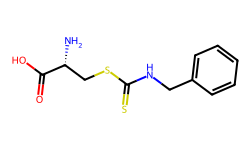

Scaffold: 


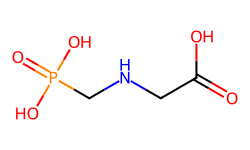


 Top 2 scaffolds from drugbank:
Scaffold: 


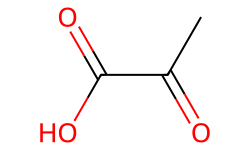

Scaffold: c1ccccc1


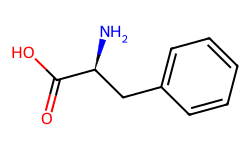


 Top 2 scaffolds from zinc:
Scaffold: c1ccccc1


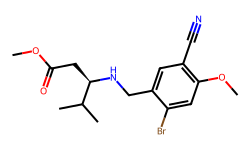

Scaffold: c1ccncc1


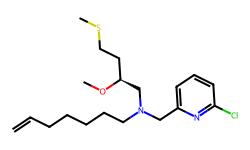

In [9]:
# top 2 most common scaffolds per source
for source in structures['source'].unique():
    source_data = structures[structures['source'] == source]
    top_scaff = source_data['scaffold'].value_counts().head(2).index
    print(f"\n Top 2 scaffolds from {source}:")
    for scaff in top_scaff:
        sub = source_data[source_data['scaffold'] == scaff].iloc[0]
        mol = sub['mol']
        print(f'Scaffold: {scaff}')
        if mol:
            display(Draw.MolToImage(mol, size=(250,150)))

## Lipinski filtering
- Number of H-bond donors over 5.
- Number of H-bond acceptors over 10.
- Molecular weight over 500 g/mol.
- LogP over 5.

In [10]:
# lipinski violations
structures['hbd_violation'] = structures['mol'].apply(lambda m: Descriptors.NumHDonors(m) > 5 if m is not None else False)
structures['hba_violation'] = structures['mol'].apply(lambda m: Descriptors.NumHAcceptors(m) > 10 if m is not None else False)
structures['heavy_violation'] = structures['mol'].apply(lambda m: Descriptors.ExactMolWt(m) > 500 if m is not None else False)
structures['greasy_violation'] = structures['mol'].apply(lambda m: Descriptors.MolLogP(m) > 5 if m is not None else False)

print("Overall number of violations: ")
print(f"Too many H-bond donors: {sum(structures['hbd_violation'] == True)}")
print(f"Too many H-bond acceptors: {sum(structures['hba_violation'] == True)}")
print(f"Too heavy: {sum(structures['heavy_violation'] == True)}")
print(f"Too greasy: {sum(structures['greasy_violation'] == True)}")
print(f"Total ligands: {len(structures['mol'])}")

Overall number of violations: 
Too many H-bond donors: 697
Too many H-bond acceptors: 548
Too heavy: 1059
Too greasy: 781
Total ligands: 14635


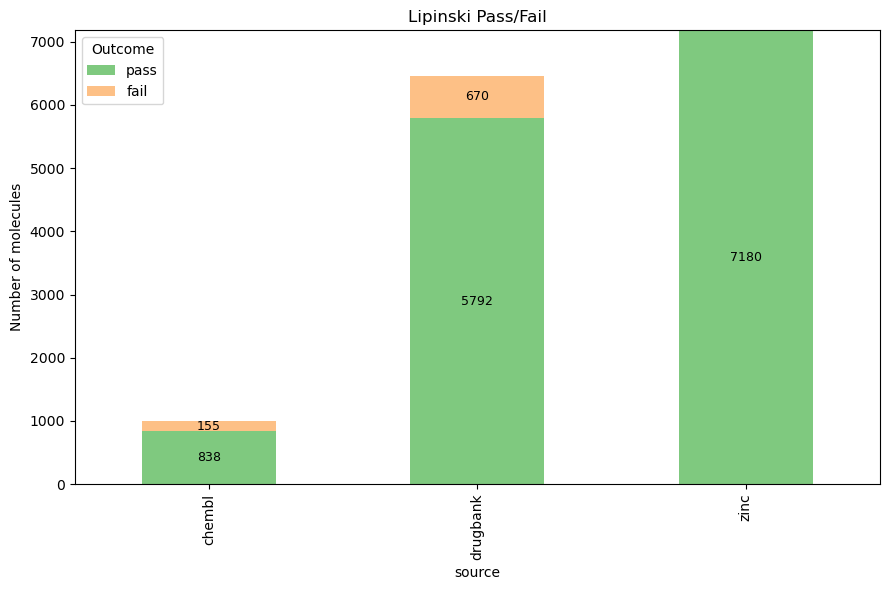

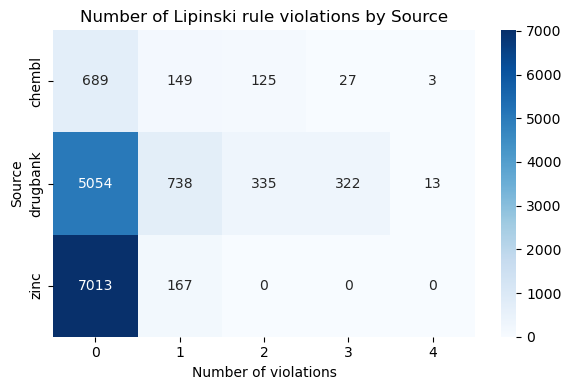

In [11]:
# number of violations
structures['num_violations'] = structures[['hbd_violation','hba_violation','heavy_violation','greasy_violation']].astype(int).sum(axis=1)
structures['fails_lipinski'] = structures['num_violations'] > 1

# group by source
counts = structures.groupby('source')['fails_lipinski'].value_counts().unstack(fill_value=0).rename(columns={False: 'pass', True: 'fail'})

# count pass/fail by source
fig, ax = plt.subplots(figsize=(9, 6))
counts[['pass','fail']].plot(kind='bar', stacked=True, color=['#7fc97f','#fdc086'], ax=ax)
ax.set_ylabel('Number of molecules')
ax.set_title('Lipinski Pass/Fail')
ax.legend(title='Outcome')

# annotate
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        x = p.get_x() + p.get_width() / 2
        y = p.get_y() + height / 2
        ax.text(x, y, int(height), ha='center', va='center', fontsize=9)

plt.tight_layout()
plt.show()

breakdown = structures.groupby('source')['num_violations'].value_counts().unstack(fill_value=0).sort_index(axis=1)
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(breakdown, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Number of Lipinski rule violations by Source')
ax.set_xlabel('Number of violations')
ax.set_ylabel('Source')
plt.tight_layout()
plt.show()


# Chemical Space Analysis

## Fingerprints
 - Morgan fingerprints are computed for all molecules
    - Radius 4, 2048 bits
 - MACCS keys are also computed for all molecules
 - TSNE is used to visualize the chemical space of the dataset, colored by data source

In [12]:
morgan_gen = AllChem.GetMorganGenerator(radius=4, fpSize=2048)

structures['morgan'] = structures['mol'].apply(lambda mol: morgan_gen.GetFingerprint(mol))
structures['morgan_np'] = structures['mol'].apply(lambda mol: morgan_gen.GetFingerprintAsNumPy(mol))

structures['maccs'] = structures['mol'].apply(lambda mol: rdMolDescriptors.GetMACCSKeysFingerprint(mol))

# Chemical Space Visualization
 - TSNE plot of the chemical space, colored by data source (ChemBL, DrugBank, Zinc)

In [13]:
from sklearn.manifold import TSNE

tsne_file = 'tsne_embs.pkl'

if os.path.exists(tsne_file):
    with open(tsne_file, 'rb') as f:
        tsne_embs = pkl.load(f)
else:
    X_fp = np.stack(structures['morgan_np'].values).astype(bool)

    tsne = TSNE(n_components=2, random_state=42, metric='jaccard', n_jobs=-1)
    tsne_embs = tsne.fit_transform(X_fp)

    with open(tsne_file, 'wb') as f:
        pkl.dump(tsne_embs, f)

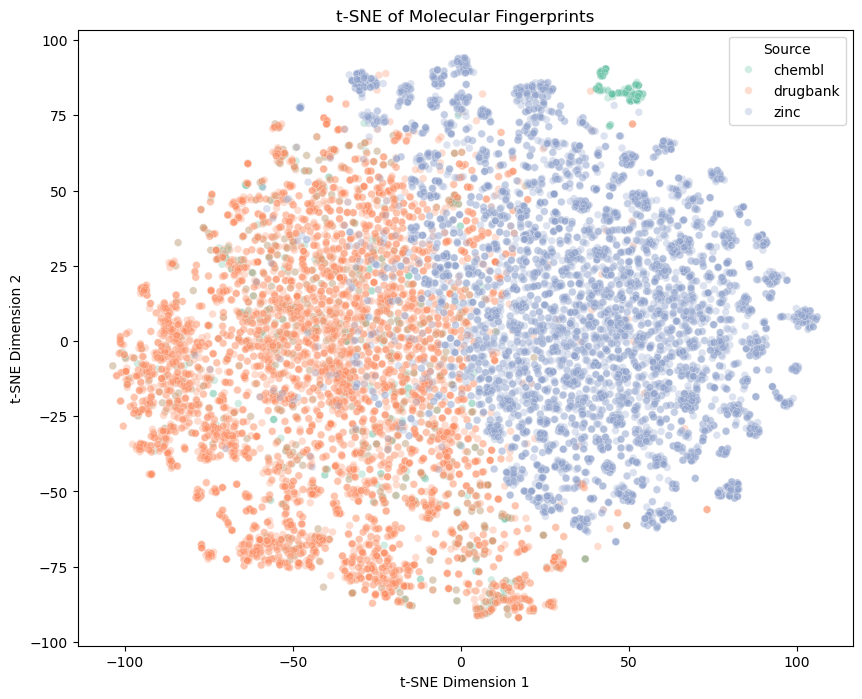

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.scatterplot(x=tsne_embs[:, 0], y=tsne_embs[:, 1], hue=structures['source'], palette='Set2', s=30, alpha=0.3)
plt.title('t-SNE of Molecular Fingerprints')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(title='Source')
plt.show()

## Scaffold Generation
 - Murcko scaffolds are generated for all molecules

In [15]:
from rdkit.Chem.Scaffolds.MurckoScaffold import GetScaffoldForMol

def scaffold_smiles(mol):
    scaffold = Chem.Scaffolds.MurckoScaffold.GetScaffoldForMol(mol)
    return Chem.MolToSmiles(scaffold)

structures['scaffold'] = structures['mol'].apply(scaffold_smiles)

# Activity Prediction

## Activity Assessment
 - Missing Ki values are imputed with a high Ki (presumed not active)
 - A threshold for activity is estimated based on borderline active compounds and visual examination of the Ki distribution
 - Activity is defined as Ki < 2000 nM

993

active (< 1000): 153
borderline (1000 <= Ki < 10000): 4
inactive (>= 10000): 836
bordereline values: [np.float64(1300.0), np.float64(1300.0), np.float64(4260.0), np.float64(5100.0)]


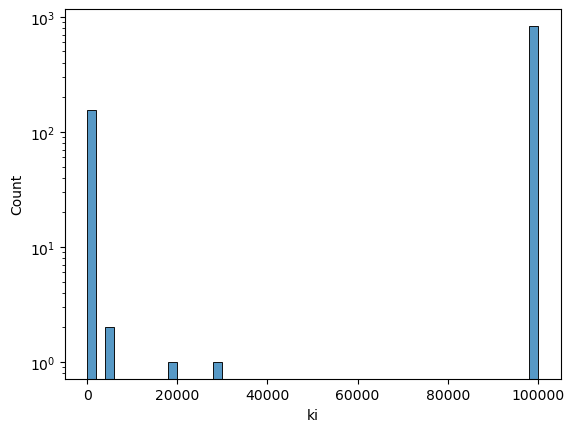

In [16]:
chembl = structures[structures['source'] == 'chembl']
display(chembl['ki'].shape[0])

kis = chembl['ki'].fillna(100000) # Assuming high Ki to missing values

thresholds = [1000, 10000]

n_active = kis[kis < thresholds[0]].shape[0]
n_borderline = kis[(kis >= thresholds[0]) & (kis < thresholds[1])].shape[0]
n_inactive = kis[kis >= thresholds[1]].shape[0]

print(f"active (< {thresholds[0]}): {n_active}")
print(f"borderline ({thresholds[0]} <= Ki < {thresholds[1]}): {n_borderline}")
print(f"inactive (>= {thresholds[1]}): {n_inactive}")

print(f"bordereline values: {sorted(kis[(kis >= thresholds[0]) & (kis < thresholds[1])].values)}")

sns.histplot(kis, bins=50)
plt.yscale('log')

In [17]:
threshold = 2000 # Chosen visually from the histogram and borderline values
pos_scale = kis[kis >= threshold].shape[0] / kis[kis < threshold].shape[0]

chembl['is_active'] = (chembl['ki'] < threshold).astype(int)

## Stratified Group Splitting
 - Stratified, so that both actives and inactives are represented
 - Grouped, so that all data points for a given scaffold are in the same split to prevent data leakage

In [18]:
from sklearn.model_selection import StratifiedGroupKFold

X_morgan = np.stack(chembl['morgan_np'].values).astype(bool)
X_maccs = np.stack(chembl['maccs'].values).astype(bool)
y = chembl['ki'].values < threshold
groups = chembl['scaffold'].values

# StratifiedGroupShuffleSplit does not exits, so we will to a 
# StratifiedGroupKFold with K=5 and take the first split as our test split (80/20)
gss = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, test_idx = next(gss.split(X_morgan, y, groups))
X_morgan_train, X_morgan_test = X_morgan[train_idx], X_morgan[test_idx]
X_maccs_train, X_maccs_test = X_maccs[train_idx], X_maccs[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train, groups_test = groups[train_idx], groups[test_idx]

## Logistic Regression
 - Using Lasso for feature selection
 - The number of non-zero coefficients $(|coef| > 10^{-6})$ is reported
 - Corresponding features are visualized below
 - We also try it with MACCS keys and print the significant features

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score
from sklearn.metrics import make_scorer, f1_score

logres_model = LogisticRegression(class_weight='balanced', l1_ratio=1, max_iter=1000, random_state=42, solver='liblinear')
cv = StratifiedGroupKFold(n_splits=5)
f1_scorer = make_scorer(f1_score)
scores = cross_val_score(logres_model, X_morgan_train, y_train, cv=cv.split(X_morgan_train, y_train, groups_train), scoring=f1_scorer, n_jobs=-1)
print(f"Logistic Regression CV F1: {scores.mean():.3f} ± {scores.std():.3f}")
non_zero_coefs = (np.abs(logres_model.fit(X_morgan_train, y_train).coef_) > 1e-6).sum()
print(f"Number of non-zero coefficients: {non_zero_coefs}")

Logistic Regression CV F1: 0.961 ± 0.020
Number of non-zero coefficients: 31


In [20]:
best_coefs = pd.DataFrame({
    'bit_index': np.arange(X_morgan_train.shape[1]),
    'coef': logres_model.fit(X_morgan_train, y_train).coef_[0],
})

best_coefs['abs_coef'] = best_coefs['coef'].abs()
best_coefs = best_coefs.sort_values(by='abs_coef', ascending=False).head(10)

In [21]:
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem import Draw

def image_for_bit(bit):
    active_row_indices = np.where(X_morgan_train[:, bit] == 1)[0]
    if len(active_row_indices) > 0:
        first_active_row = active_row_indices[0]

        original_idx = train_idx[first_active_row]
        mol = chembl.iloc[original_idx]['mol']
        
        ao = rdFingerprintGenerator.AdditionalOutput()
        ao.AllocateBitInfoMap()
        fp = morgan_gen.GetFingerprint(mol, additionalOutput=ao)
        info = ao.GetBitInfoMap()

        img = Draw.DrawMorganBits(
            [(mol, bit, info)],
            molsPerRow=1,
        )
        return img
    return None

bit_index,coefficient,image
1504,2.168,
662,2.129,
739,2.020,
1870,1.937,
558,1.792,
1341,1.555,
942,1.447,
314,-1.313,
586,0.986,
1827,0.859,

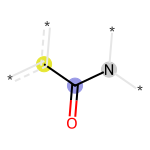
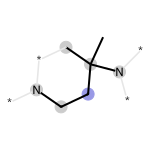
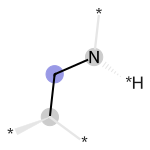
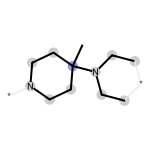
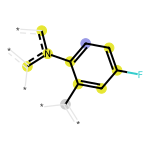
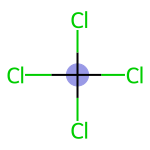
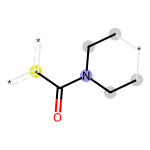
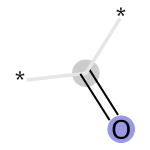
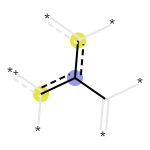
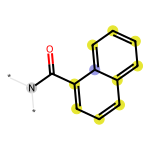

In [22]:
from IPython.display import HTML
import base64
from io import BytesIO

def img_to_base64(img):
    buffer = BytesIO()
    img.save(buffer, format='PNG')
    return base64.b64encode(buffer.getvalue()).decode('utf-8')

def to_displayable_image(img):
    css = "width: 150px; height: 150px; min-width: 150px; max-width: 150px; object-fit: contain; background-color: white; border: 1px solid #ccc; box-sizing: border-box;"
    if img is not None:
        return f"<img src='data:image/png;base64,{img_to_base64(img)}' style='{css}'/>"
    return f"<div style='{css} display: flex; align-items: center; justify-content: center; color: #666; font-family: sans-serif;'>No image</div>"

def color_sign(val):
    color = 'green' if val > 0 else 'red'
    # Adding bold text to make it pop!
    return f"<span style='color: {color}; font-weight: bold;'>{val:.3f}</span>"

best_coefs['image'] = best_coefs['bit_index'].apply(image_for_bit).apply(to_displayable_image)
best_coefs['coefficient'] = best_coefs['coef'].apply(color_sign)
best_coefs = best_coefs[['bit_index', 'coefficient', 'image']]
display(HTML(best_coefs.to_html(escape=False, index=False)))

In [23]:
logres_model = LogisticRegression(class_weight='balanced', l1_ratio=1, max_iter=1000, random_state=42, solver='liblinear', C=1)
cv = StratifiedGroupKFold(n_splits=5)
f1_scorer = make_scorer(f1_score)
scores = cross_val_score(logres_model, X_maccs_train, y_train, cv=cv.split(X_maccs_train, y_train, groups_train), scoring=f1_scorer, n_jobs=-1)
print(f"Logistic Regression CV F1: {scores.mean():.3f} ± {scores.std():.3f}")
non_zero_coefs = (np.abs(logres_model.fit(X_maccs_train, y_train).coef_) > 1e-6).sum()
print(f"Number of non-zero coefficients: {non_zero_coefs}")

Logistic Regression CV F1: 0.926 ± 0.048
Number of non-zero coefficients: 43


MACCS_Key,coefficient,SMARTS,image
96,-2.008,*1~*~*~*~*~1,
149,1.648,"[C;H3,H4]",
92,1.628,[#8]~[#6](~[#7])~[#6],
133,1.492,*@*!@[#7],
89,-1.282,[#8]~*~*~*~[#8],
125,1.206,?,No image
143,-1.120,*@*!@[#8],
112,0.974,*~*(~*)(~*)~*,
62,0.943,*@*!@*@*,
42,0.934,F,

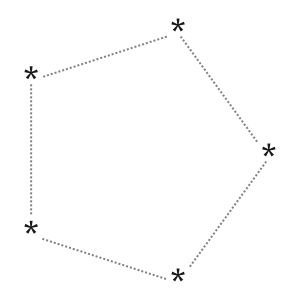
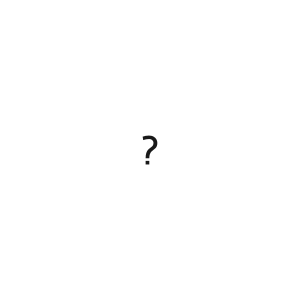
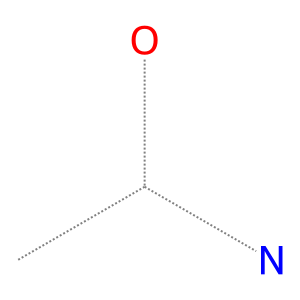
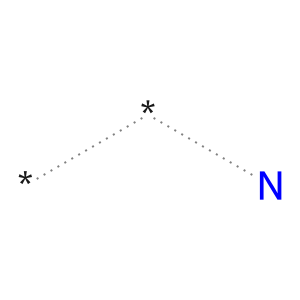
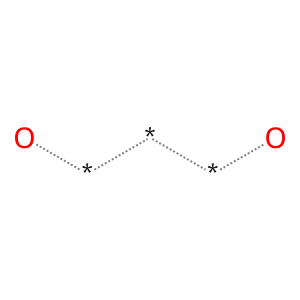
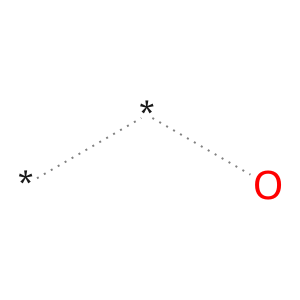
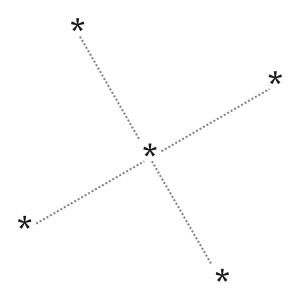
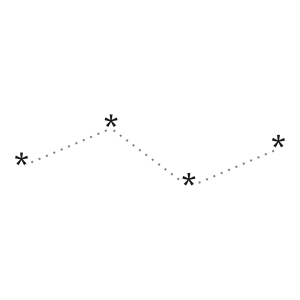
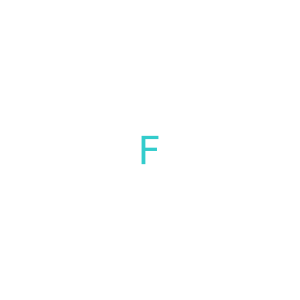

In [24]:
from rdkit.Chem import MACCSkeys
from PIL import Image

maccs_dict = MACCSkeys.smartsPatts
results = []

for bit_idx in range(0, len(logres_model.coef_[0])):
    coef = logres_model.coef_[0][bit_idx]

    if bit_idx in maccs_dict:
        smarts_pattern = maccs_dict[bit_idx][0]
        pattern_mol = Chem.MolFromSmarts(smarts_pattern)
        img = Draw.MolToImage(pattern_mol) if pattern_mol else None
    else:
        smarts_pattern = "Unknown"
        img = None
        
    results.append({
        'MACCS_Key': bit_idx,
        'SMARTS': smarts_pattern,
        'coef': coef,
        'abs_coef': np.abs(coef),
        'image': img
    })

maccs_df = pd.DataFrame(results).sort_values(by='abs_coef', ascending=False).head(10)

maccs_df['coefficient'] = maccs_df['coef'].apply(color_sign)
maccs_df['image'] = maccs_df['image'].apply(to_displayable_image)

maccs_df = maccs_df[['MACCS_Key', 'coefficient', 'SMARTS', 'image']]
display(HTML(maccs_df.to_html(escape=False, index=False)))

## XGBoost
 - Hyperparameter tuning with Optuna
 - Feature importance analysis to identify the most influential bits in the fingerprint, and the corresponding substructures visualized below
 - We also calculate SHAP values to determine whether the contribution is positive or negative
 - Performs slightly better than logistic regression

In [25]:
import optuna
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score
from sklearn.metrics import make_scorer, f1_score, roc_auc_score

def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 2, 7),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-5, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-5, 10.0, log=True),
        'scale_pos_weight': pos_scale,
        'random_state': 42,
        'eval_metric': 'logloss'
    }
    
    model = XGBClassifier(**param)
    cv = StratifiedGroupKFold(n_splits=5)
    
    f1_scorer = make_scorer(f1_score)
    scores = cross_val_score(
        model, 
        X_morgan_train, 
        y_train, 
        groups=groups_train, 
        scoring=f1_scorer, 
        cv=cv, 
        n_jobs=-1
    )
    
    return scores.mean()

sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction='maximize', study_name="XGBoost_CCR5_Optimization", sampler=sampler)

study.optimize(objective, n_trials=20)

[I 2026-05-21 11:26:54,445] A new study created in memory with name: XGBoost_CCR5_Optimization
[I 2026-05-21 11:26:55,939] Trial 0 finished with value: 0.9530766852195424 and parameters: {'n_estimators': 250, 'max_depth': 7, 'learning_rate': 0.1205712628744377, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'gamma': 0.15599452033620265, 'reg_alpha': 2.231010801867923e-05, 'reg_lambda': 1.5741890047456624}. Best is trial 0 with value: 0.9530766852195424.
[I 2026-05-21 11:26:56,673] Trial 1 finished with value: 0.9301875295572775 and parameters: {'n_estimators': 341, 'max_depth': 6, 'learning_rate': 0.010725209743171997, 'subsample': 0.9849549260809971, 'colsample_bytree': 0.9162213204002109, 'gamma': 0.21233911067827616, 'reg_alpha': 0.00012329623163659834, 'reg_lambda': 0.00012601639723276795}. Best is trial 0 with value: 0.9530766852195424.
[I 2026-05-21 11:26:57,194] Trial 2 finished with value: 0.9486549165120595 and parameters: {'n_estimators': 222, 'max_d

In [26]:
best_xgb_model = XGBClassifier(**study.best_params, scale_pos_weight=pos_scale, random_state=42, eval_metric='logloss')
best_model_avg_roc_auc = cross_val_score(
    best_xgb_model, 
    X_morgan_train, 
    y_train, 
    groups=groups_train, 
    scoring=make_scorer(roc_auc_score), 
    cv=cv, 
    n_jobs=-1
)
best_model_avg_f1 = cross_val_score(
    best_xgb_model, 
    X_morgan_train, 
    y_train, 
    groups=groups_train, 
    scoring=make_scorer(f1_score), 
    cv=cv, 
    n_jobs=-1
)
best_xgb_model.fit(X_morgan_train, y_train)
print(f"\nBest CV F1 Score: {best_model_avg_f1.mean():.3f} ± {best_model_avg_f1.std():.3f}")
print(f"Best CV ROC-AUC Score: {best_model_avg_roc_auc.mean():.3f} ± {best_model_avg_roc_auc.std():.3f}")
print("Best Parameters:")
for key, value in study.best_params.items():
    print(f"\t{key}: {value}")


Best CV F1 Score: 0.968 ± 0.021
Best CV ROC-AUC Score: 0.978 ± 0.017
Best Parameters:
	n_estimators: 275
	max_depth: 2
	learning_rate: 0.1645175874849597
	subsample: 0.8233164424260212
	colsample_bytree: 0.6637452938214105
	gamma: 0.2139959323216131
	reg_alpha: 1.6513110208566488e-05
	reg_lambda: 0.043346328047614936


In [27]:
import shap

best_fis = pd.DataFrame({
    'bit_index': np.arange(X_morgan_train.shape[1]),
    'importance': best_xgb_model.feature_importances_,
}).sort_values(by='importance', ascending=False).head(20)

explainer = shap.TreeExplainer(best_xgb_model)
shap_values = explainer.shap_values(X_morgan_train)
shaps = []
for bit in best_fis['bit_index']:
    active_rows_mask = (X_morgan_train[:, bit] == 1)
    if active_rows_mask.sum() > 0:
        mean_shap_when_present = shap_values[active_rows_mask, bit].mean()
        shaps.append(mean_shap_when_present)
    else:
        shaps.append(0.0)

best_fis['shap'] = list(map(color_sign, shaps))

bit_index,importance,shap,image
2009,0.312309,1.890,
942,0.109840,1.223,
925,0.059514,0.874,
983,0.046331,1.057,
1504,0.039594,1.243,
586,0.038749,0.511,
1827,0.031329,0.919,
1877,0.028985,0.474,
665,0.026783,0.236,
662,0.025116,1.156,

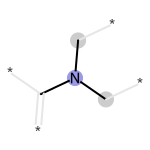
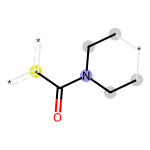
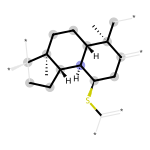
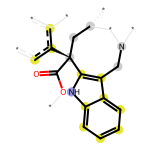
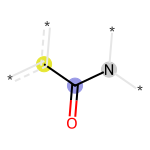
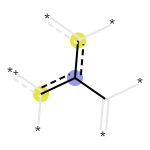
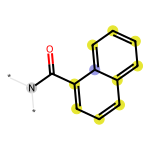
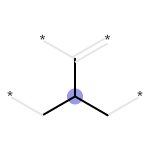
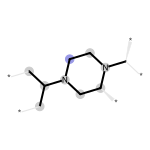
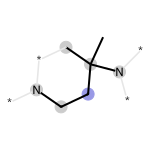
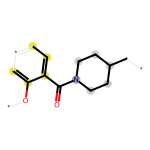
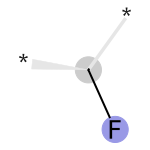
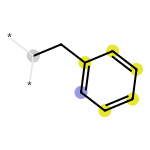
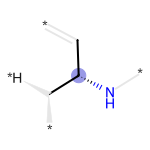
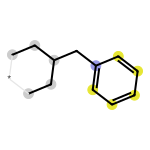
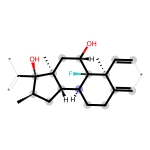
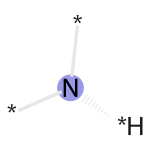
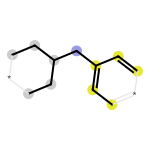
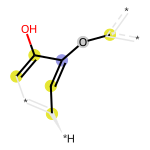
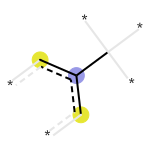

In [28]:
best_fis['image'] = best_fis['bit_index'].apply(image_for_bit).apply(to_displayable_image)
display(HTML(best_fis.to_html(escape=False, index=False)))

### Discussion
 - Significant features identified by both models are generally very similar
 - Even the MACCS smarts can generally be found in the significant substructures identified by Morgan FPs
 - Both models perform similarly, with XGBoost having a slight edge in F1 score

,0,1,2,3,4,5,6,7,8,9
lasso,,,,,,,,,,
lasso_coef,2.168,2.129,2.020,1.937,1.792,1.555,1.447,-1.313,0.986,0.859
lasso_maccs,,,,,,No image,,,,
lasso_maccs_smarts,*1~*~*~*~*~1,"[C;H3,H4]",[#8]~[#6](~[#7])~[#6],*@*!@[#7],[#8]~*~*~*~[#8],?,*@*!@[#8],*~*(~*)(~*)~*,*@*!@*@*,F
lasso_maccs_coeff,-2.008,1.648,1.628,1.492,-1.282,1.206,-1.120,0.974,0.943,0.934
xgboost,,,,,,,,,,
xgboost_shap,1.890,1.223,0.874,1.057,1.243,0.511,0.919,0.474,0.236,1.156

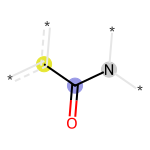
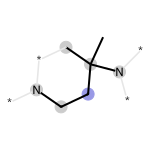
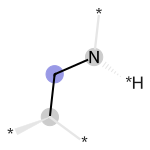
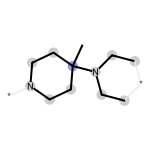
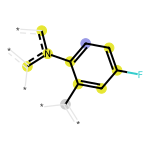
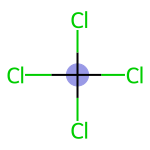
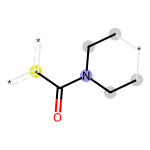
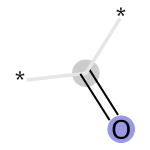
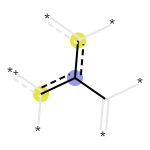
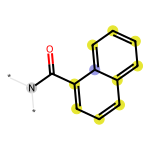
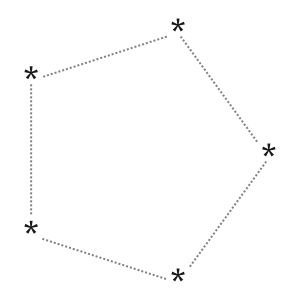
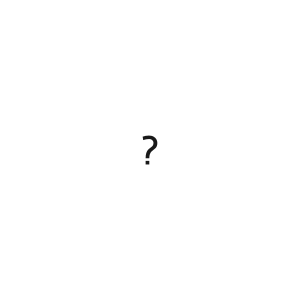
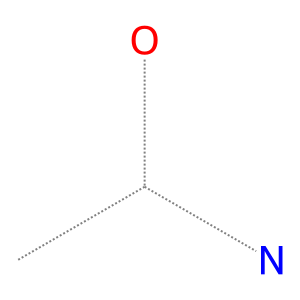
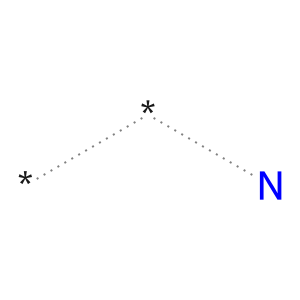
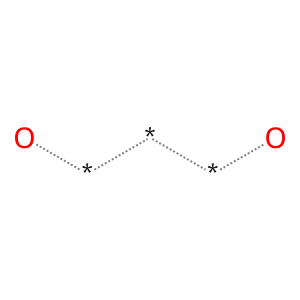
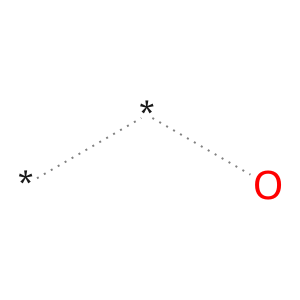
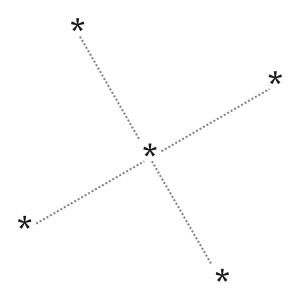
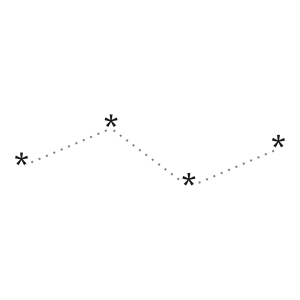
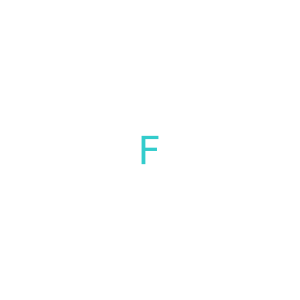
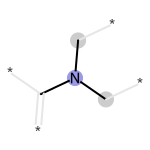
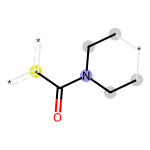
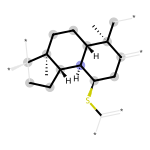
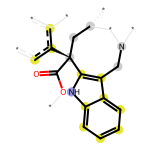
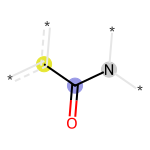
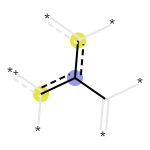
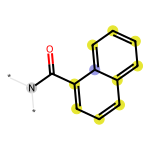
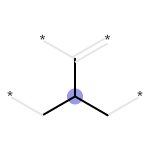
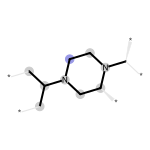
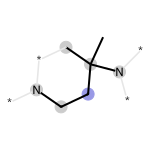

In [29]:
display(HTML(pd.DataFrame({
    'lasso': best_coefs.head(10)['image'].reset_index(drop=True),
    'lasso_coef': best_coefs.head(10)['coefficient'].reset_index(drop=True),
    'lasso_maccs': maccs_df.head(10)['image'].reset_index(drop=True),
    'lasso_maccs_smarts': maccs_df.head(10)['SMARTS'].reset_index(drop=True),
    'lasso_maccs_coeff': maccs_df.head(10)['coefficient'].reset_index(drop=True),
    'xgboost': best_fis.head(10)['image'].reset_index(drop=True),
    'xgboost_shap': best_fis.head(10)['shap'].reset_index(drop=True)
}).T.to_html(escape=False, index=True)))

## Model Selection
 - Based on CV F1 Score, XGBoost is selected as the best model (with optuna-tuned hyperparameters)
 - Performance on a novel set is predicted on the held-out test set

In [30]:
f1_score = f1_score(y_test, best_xgb_model.predict(X_morgan_test))
roc_auc = roc_auc_score(y_test, best_xgb_model.predict_proba(X_morgan_test)[:, 1])
print(f"Test F1 Score: {f1_score:.3f}")
print(f"Test ROC-AUC Score: {roc_auc:.3f}")

Test F1 Score: 0.951
Test ROC-AUC Score: 0.980


## Prediction on ZINC and DrugBank
 - Using the best model (XGBoost) to predict on external datasets
 - Top predicted actives are visualized with their predicted probabilities

id,source,mol,prediction,proba,image
ZINCta00000hiE2V,zinc,,active,0.998671,
ZINCoc0000065mrh,zinc,,active,0.998531,
ZINCtC000001Fw5j,zinc,,active,0.996036,
ZINCty00000CNCHc,zinc,,active,0.995178,
DB04835,drugbank,,active,0.994275,
ZINCoc0000065mGL,zinc,,active,0.991254,
ZINCqu00000nPy67,zinc,,active,0.988586,
DB07936,drugbank,,active,0.988325,
ZINCsF00000ay712,zinc,,active,0.987441,
ZINCqu00000nPy6g,zinc,,active,0.987263,

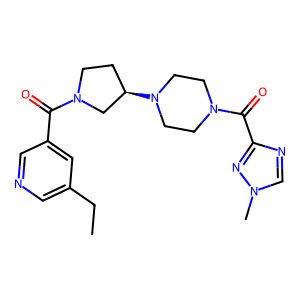
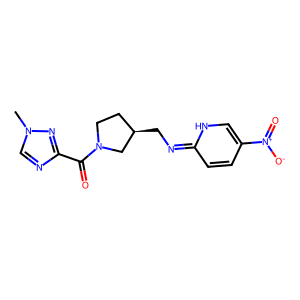
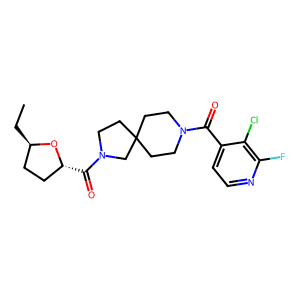
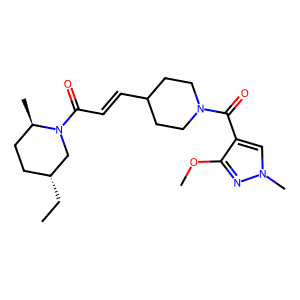
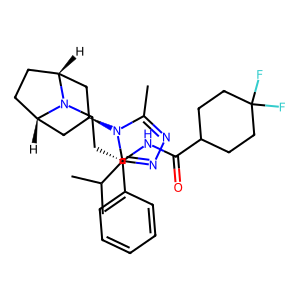
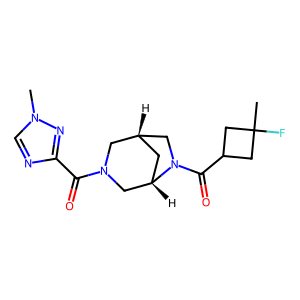
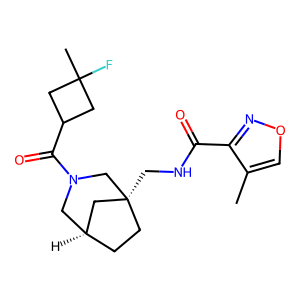
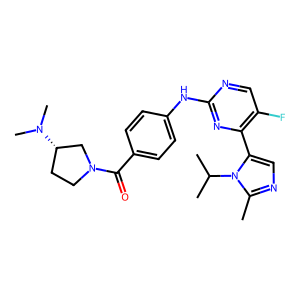
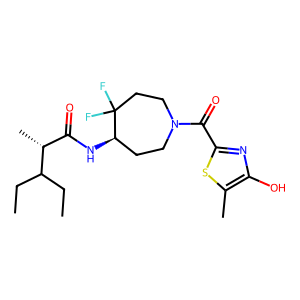
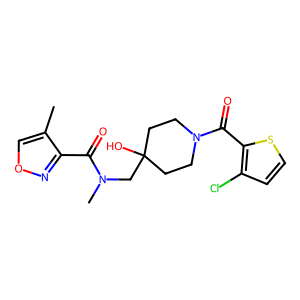

In [31]:
non_chemb = structures[structures['source'] != 'chembl']
best_xgb_model.predict(non_chemb['morgan_np'].tolist())
non_chemb['prediction'] = best_xgb_model.predict(non_chemb['morgan_np'].tolist())
non_chemb['proba'] = best_xgb_model.predict_proba(non_chemb['morgan_np'].tolist())[:, 1]
non_chemb['prediction'] = non_chemb['prediction'].apply(lambda x: "active" if x == 1 else "inactive")

top_hits = pd.DataFrame({
    'id': non_chemb['id'],
    'source': non_chemb['source'],
    'mol': non_chemb['mol'],
    'prediction': non_chemb['prediction'],
    'proba': non_chemb['proba']
}).sort_values(by='proba', ascending=False).head(10)

top_hits['image'] = top_hits['mol'].apply(Draw.MolToImage).apply(to_displayable_image)
display(HTML(top_hits.to_html(escape=False, index=False)))